---
title: 'Exercise Solutions: Reviewing Supervised Linear Models'
author: Mark Fuge
format:
    html:
        code-fold: true
        code-summary: "Show Solution Code"
---

These are worked solutions to the exercises at the end of the chapter *Reviewing Supervised Linear Models*. You should just be able to run this notebook in isolation, since we regenerate any necessary examples/data.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
from scipy.optimize import fmin
from sklearn.datasets import make_classification, make_moons, make_regression
from sklearn.linear_model import HuberRegressor, LinearRegression, SGDClassifier, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

warnings.simplefilter('ignore', RuntimeWarning)

# --- Outlier data from the robust-regression section (same seeds as the chapter) ---
n_samples = 1000
n_outliers = 50
Xr, yr, coef = make_regression(n_samples=n_samples, n_features=1, n_informative=1,
                               noise=10, coef=True, random_state=0)
np.random.seed(0)
Xr[:n_outliers] = 3 + 0.5 * np.random.normal(size=(n_outliers, 1))
yr[:n_outliers] = -3 + 10 * np.random.normal(size=n_outliers)
yr /= 10
yr += 10
true_slope_outliers = coef / 10   # the rescaling divides the true slope by 10 as well

# --- 2D classification datasets from the classification section ---
X_sep, y_sep = make_classification(n_features=2, n_redundant=0, n_informative=2, random_state=1,
                                   n_clusters_per_class=1, flip_y=0.0, class_sep=0.7)
datasets = [make_moons(noise=0.3, random_state=0), None, (X_sep, y_sep)]

# --- Line data from the penalty section (same generator and seed family as the chapter) ---
w1_true, w0_true, noise = 5, 2, 0.001
num_samples = 50
np.random.seed(2)   # same explicit seed as the chapter
x_line = (np.random.rand(num_samples) - 0.5) * 20
y_line = w1_true * x_line + w0_true + np.random.normal(scale=noise, size=num_samples)


def loss(a, b, alpha, order=2):
    """Training MSE of the line y = a x + b plus an L_order penalty of weight alpha."""
    return np.average((y_line - (a * x_line + b))**2) + alpha * norm([a, b], ord=order)


A, B = np.meshgrid(np.linspace(-10, 10, 201), np.linspace(-10, 10, 201))
N, M = A.shape
floss = np.vectorize(loss)


def generate_z_grid(alpha, order):
    """Objective on the (a, b) grid without and with the penalty, plus the grid minimum."""
    Z_noalpha = floss(A.flatten(), B.flatten(), 0).reshape((N, M))
    Z = floss(A.flatten(), B.flatten(), alpha, order)
    min_ind = np.argmin(Z)
    return Z_noalpha, Z.reshape((N, M)), A.flatten()[min_ind], B.flatten()[min_ind]


get_levels = lambda z: [np.percentile(z.flatten(), i) for i in [0, 0.5, 1, 2, 5, 10, 15, 30, 40, 50, 75, 95, 100]]

### Exercise 1: Is it linear?

The test is always the same: hold the inputs fixed and ask whether the prediction is a weighted sum of known quantities with the unknown parameters as the weights.

| Model | Verdict | Why |
|---|---|---|
| (a) $y = w_0 + w_1 x + w_2 x^2$ | linear | Features $[1, x, x^2]$, weights $[w_0, w_1, w_2]$. |
| (b) $y = a\,e^{bx}$ | linear after $\log$ | $\log y = \log a + b\,x$: features $[1, x]$, weights $[\log a, b]$. |
| (c) $y = w_0 + w_1 \log x + w_2 \sqrt{x}$ | linear | Features $[1, \log x, \sqrt{x}]$. The features are non-linear in $x$, which is fine. |
| (d) $y = w_1 \sin(w_2 x)$ | not linear | $w_2$ sits inside the sine; no transformation of $y$ or $x$ pulls it out. (You could fix a grid of candidate frequencies and treat each $\sin(\omega_k x)$ as a feature, but that is a different model.) |
| (e) $y = a\,x^{b}$ | linear after $\log$–$\log$ | $\log y = \log a + b \log x$. This is exactly how S-N (Basquin) curves are fit on log-log paper. |
| (f) $y = w_0 + w_1/(w_2 + x)$ | not linear as written | $w_2$ sits inside the denominator. If $w_2$ were known you would have features $[1, 1/(w_2 + x)]$; in practice one can set or search through possible $w_2$s and then you can solve a linear problem for each candidate. |
| (g) $y = 1/(w_0 + w_1 x)$ | linear after reciprocal | $1/y = w_0 + w_1 x$. |

**On the noise.** If $y$ carries additive Gaussian noise, then $\log y$ or $1/y$ does not: the noise becomes multiplicative and skewed, and small values of $y$ get amplified enormously (a reading of $y \approx 0$ sends $1/y$ to infinity). Fitting the transformed model with the squared loss therefore weights the data points differently from fitting the original model, which is a good reason to at least look at the residuals afterwards.

### Exercise 2: Build your own feature expansion

Each candidate is a sum of a few terms, so the "right" features are exactly those terms (plus a constant column if you want to also learn the intercept). Below, we construct each of the feature function by stacking columns of a numpy array, and then fitting that matrix is the same Linear Regression function.

In [ ]:
candidate_functions = {
    "A": lambda x: 2.0 * np.sqrt(x) + 0.5 * np.cos(3.0 * x),
    "B": lambda x: np.log(1.0 + x) + 0.1 * x**2,
    "C": lambda x: np.sin(x) + x * np.exp(-x),
    "D": lambda x: 0.2 * x**2 - 3.0 * np.sqrt(x) + np.cos(x),
}
true_weights = {"A": [2.0, 0.5], "B": [1.0, 0.1], "C": [1.0, 1.0], "D": [0.2, -3.0, 1.0]}

# One feature function per candidate: each column is one term of the candidate function
feature_functions = {
    "A": lambda x: np.column_stack([np.sqrt(x), np.cos(3.0 * x)]),
    "B": lambda x: np.column_stack([np.log(1.0 + x), x**2]),
    "C": lambda x: np.column_stack([np.sin(x), x * np.exp(-x)]),
    "D": lambda x: np.column_stack([x**2, np.sqrt(x), np.cos(x)]),
}


def sample_candidate(name, n_points=60, noise_std=0.1, seed=0):
    """Return noisy samples (x, y) of one of the candidate functions on x in [0, 5]."""
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(0.0, 5.0, n_points))
    y = candidate_functions[name](x) + rng.normal(0.0, noise_std, n_points)
    return x, y


x_new = np.array([0.5, 2.5, 4.5])
fitted_models = {}
for name in candidate_functions.keys():
    x_ex, y_ex = sample_candidate(name)
    model = LinearRegression()
    model.fit(feature_functions[name](x_ex), y_ex)
    fitted_models[name] = model
    print(f"Candidate {name}")
    print(f"  fitted weights: {np.round(model.coef_, 3)}   true: {true_weights[name]}   intercept: {model.intercept_:.3f} (true 0)")
    print(f"  prediction at x_new: {np.round(model.predict(feature_functions[name](x_new)), 3)}")
    print(f"  true value at x_new: {np.round(candidate_functions[name](x_new), 3)}")

Candidate A
  fitted weights: [1.992 0.486]   true: [2.0, 0.5]   intercept: 0.022 (true 0)
  prediction at x_new: [1.464 3.339 4.536]
  true value at x_new: [1.45  3.336 4.54 ]
Candidate B
  fitted weights: [0.964 0.102]   true: [1.0, 0.1]   intercept: 0.031 (true 0)
  prediction at x_new: [0.448 1.877 3.743]
  true value at x_new: [0.43  1.878 3.73 ]
Candidate C
  fitted weights: [0.992 1.096]   true: [1.0, 1.0]   intercept: -0.008 (true 0)
  prediction at x_new: [ 0.8    0.811 -0.922]
  true value at x_new: [ 0.783  0.804 -0.928]
Candidate D
  fitted weights: [ 0.197 -2.923  1.051]   true: [0.2, -3.0, 1.0]   intercept: -0.070 (true 0)
  prediction at x_new: [-1.166 -4.303 -2.502]
  true value at x_new: [-1.194 -4.295 -2.525]


The fitted weights match the true coefficients fairly well with only 60 noisy points, because the model has exactly the right features and only two or three parameters to learn.

For part (d), here is candidate A fit with the *wrong* features, a cubic polynomial. The polynomial can imitate the curve in the middle of the interval but has no way to reproduce $\sqrt{x}$ near $x = 0$ or the oscillation, and it drifts at the ends.

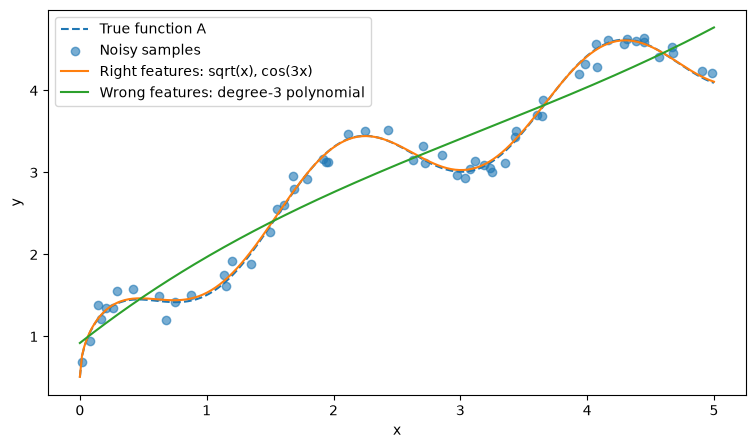

In [ ]:
x_ex, y_ex = sample_candidate("A")
x_dense = np.linspace(0, 5, 300)

poly_features = PolynomialFeatures(degree=3, include_bias=False)
wrong_model = LinearRegression().fit(poly_features.fit_transform(x_ex[:, np.newaxis]), y_ex)

plt.figure(figsize=(9, 5))
plt.plot(x_dense, candidate_functions["A"](x_dense), '--', label="True function A")
plt.scatter(x_ex, y_ex, label="Noisy samples", alpha=0.6)
plt.plot(x_dense, fitted_models["A"].predict(feature_functions["A"](x_dense)), label="Right features: sqrt(x), cos(3x)")
plt.plot(x_dense, wrong_model.predict(poly_features.transform(x_dense[:, np.newaxis])), label="Wrong features: degree-3 polynomial")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Exercise 3: Match the shrinkage path to the norm

The code below recomputes the four coefficient paths and prints which panel letter received which $p$ (the panel order was shuffled with a fixed seed in the chapter).

Panel -> p: {'A': 100, 'B': 2, 'C': 1, 'D': 0.5}


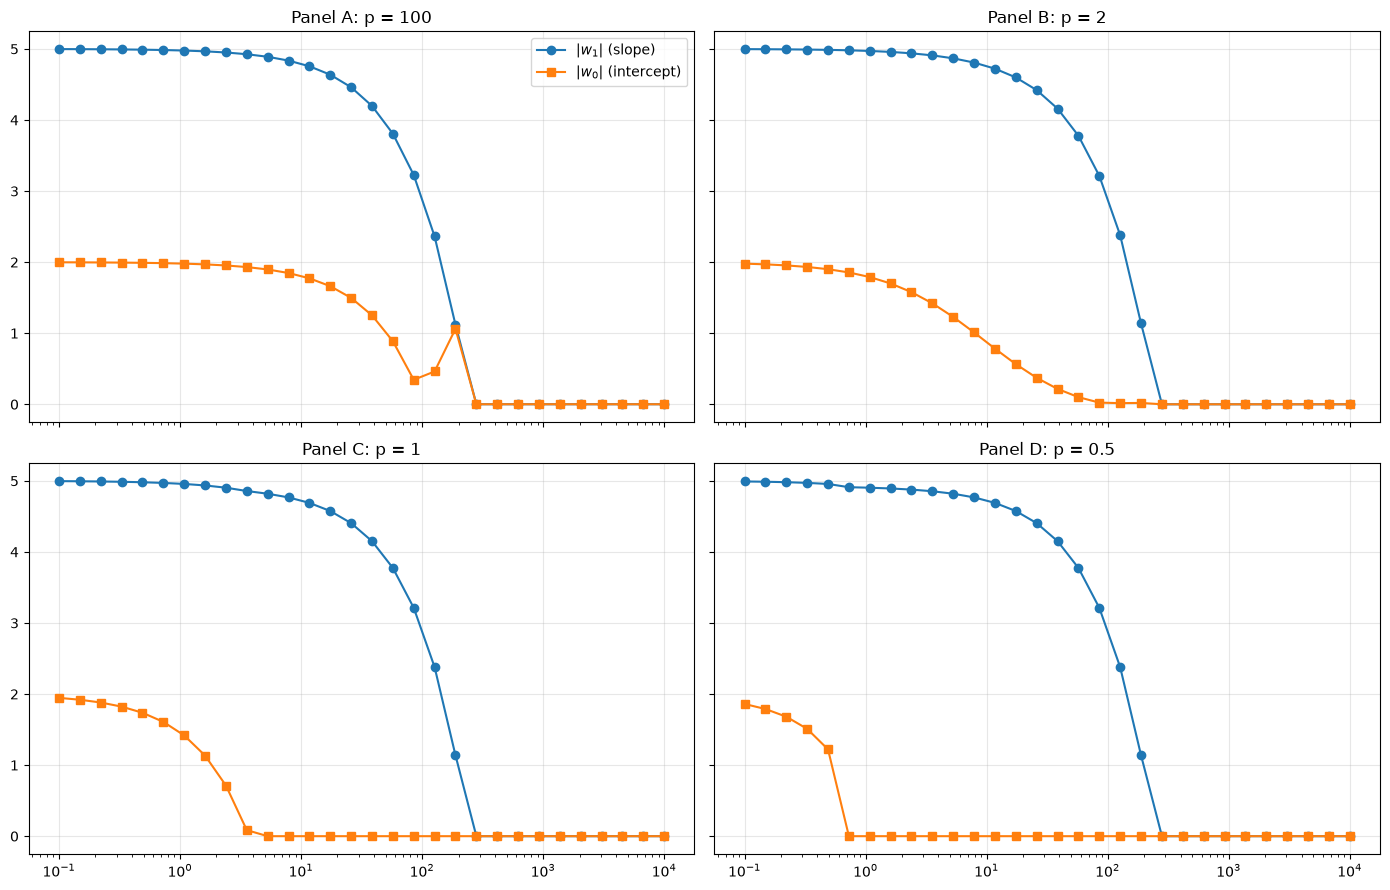

In [ ]:
ex3_orders = [0.5, 1, 2, 100]
ex3_alphas = np.logspace(-1, 4, 30)
ex3_paths = np.zeros((len(ex3_orders), len(ex3_alphas), 2))
for j, o in enumerate(ex3_orders):
    prev_opt = [5, 5]
    for i, a in enumerate(ex3_alphas):
        prev_opt = fmin(lambda v: loss(v[0], v[1], alpha=a, order=o), prev_opt, disp=False)
        ex3_paths[j, i] = prev_opt

ex3_panel_order = np.random.default_rng(3).permutation(len(ex3_orders))
print("Panel -> p:", {letter: ex3_orders[j] for letter, j in zip("ABCD", ex3_panel_order)})

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for panel, (ax, j) in enumerate(zip(axes.ravel(), ex3_panel_order)):
    ax.semilogx(ex3_alphas, np.abs(ex3_paths[j, :, 0]), 'o-', label="$|w_1|$ (slope)")
    ax.semilogx(ex3_alphas, np.abs(ex3_paths[j, :, 1]), 's-', label="$|w_0|$ (intercept)")
    ax.set_title(f"Panel {'ABCD'[panel]}: p = {ex3_orders[j]}")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

**(a)** The tell-tale features:

- $p = 100$ (essentially $L_\infty$): the penalty only cares about the *largest* coefficient, so at first the slope shrinks faster than the intercept (which shrinks, but more slowly). At the weight increases and the slope begins to contract even more aggressively, we counter-intuitively even see the intercept grow/increase again, in part to help counter-act the fact that the slope is flattening so quickly and inducing high MSE. Once the two magnitudes are equal they shrink together. This tendency to "equalize, then shrink together" is characteristic of $L_\infty$ penalties.
- $p = 2$: both coefficients shrink smoothly and neither reaches exactly zero until the penalty overwhelms the data term completely.
- $p = 1$: the intercept decays and hits *exactly* zero at a moderate $\alpha$, then stays there while the slope is still near its true value. This "induced sparsity" is one of the hallmarks of $L_1$ norms.
- $p = 0.5$: the intercept jumps to exactly zero almost immediately, at a much smaller $\alpha$ than for $p=1$, because a non-convex penalty rewards being exactly on an axis even more strongly than in the $p=1$ case. You can gain further intuition on this but trying other $p$ norms in the code cell above and testing your intuition about how they work and affect the linear model.

**(b)** The smaller coefficient is set to exactly zero while the other is still large only for $p \le 1$. The reason is the shape of the penalty's contours as we saw in the more visual example earlier in the notebook: for $p \le 1$ the penalty norm has corners on the axes, and while this doesn't necessary guarentee a coefficient goes to zero, if the loss function itself is fairly smooth (as is the case with our example), this will generally encourage the lowest point on a given norm constraint to be touching one of the axes and thus inducing sparsity. In contrast, with $p = 2$ the contours were round, so if we look for the lowest loss function that constrained to one of the lines in the penalty function is almost never exactly touching an axis; the coefficient gets small but stays non-zero. This also makes sense from a gradient perspective, since as the weight becomes small the gradient also goes to zero and this means it has less incentive to shrink the weight further. For $p = \infty$ the corners are on the diagonals, which pushes the coefficients towards *equal* magnitude rather than towards zero.

### Exercise 4: Which loss made this fit?

Fit -> loss: {'A': 'squared_error', 'B': 'huber', 'C': 'epsilon_insensitive'}
True slope of the bulk of the data: 8.219, true intercept: 10
Fit A (       squared_error): slope 5.29, intercept 9.03, median residual of the non-outliers 0.84
Fit B (               huber): slope 7.96, intercept 9.94, median residual of the non-outliers 0.04
Fit C ( epsilon_insensitive): slope 7.82, intercept 9.90, median residual of the non-outliers 0.08


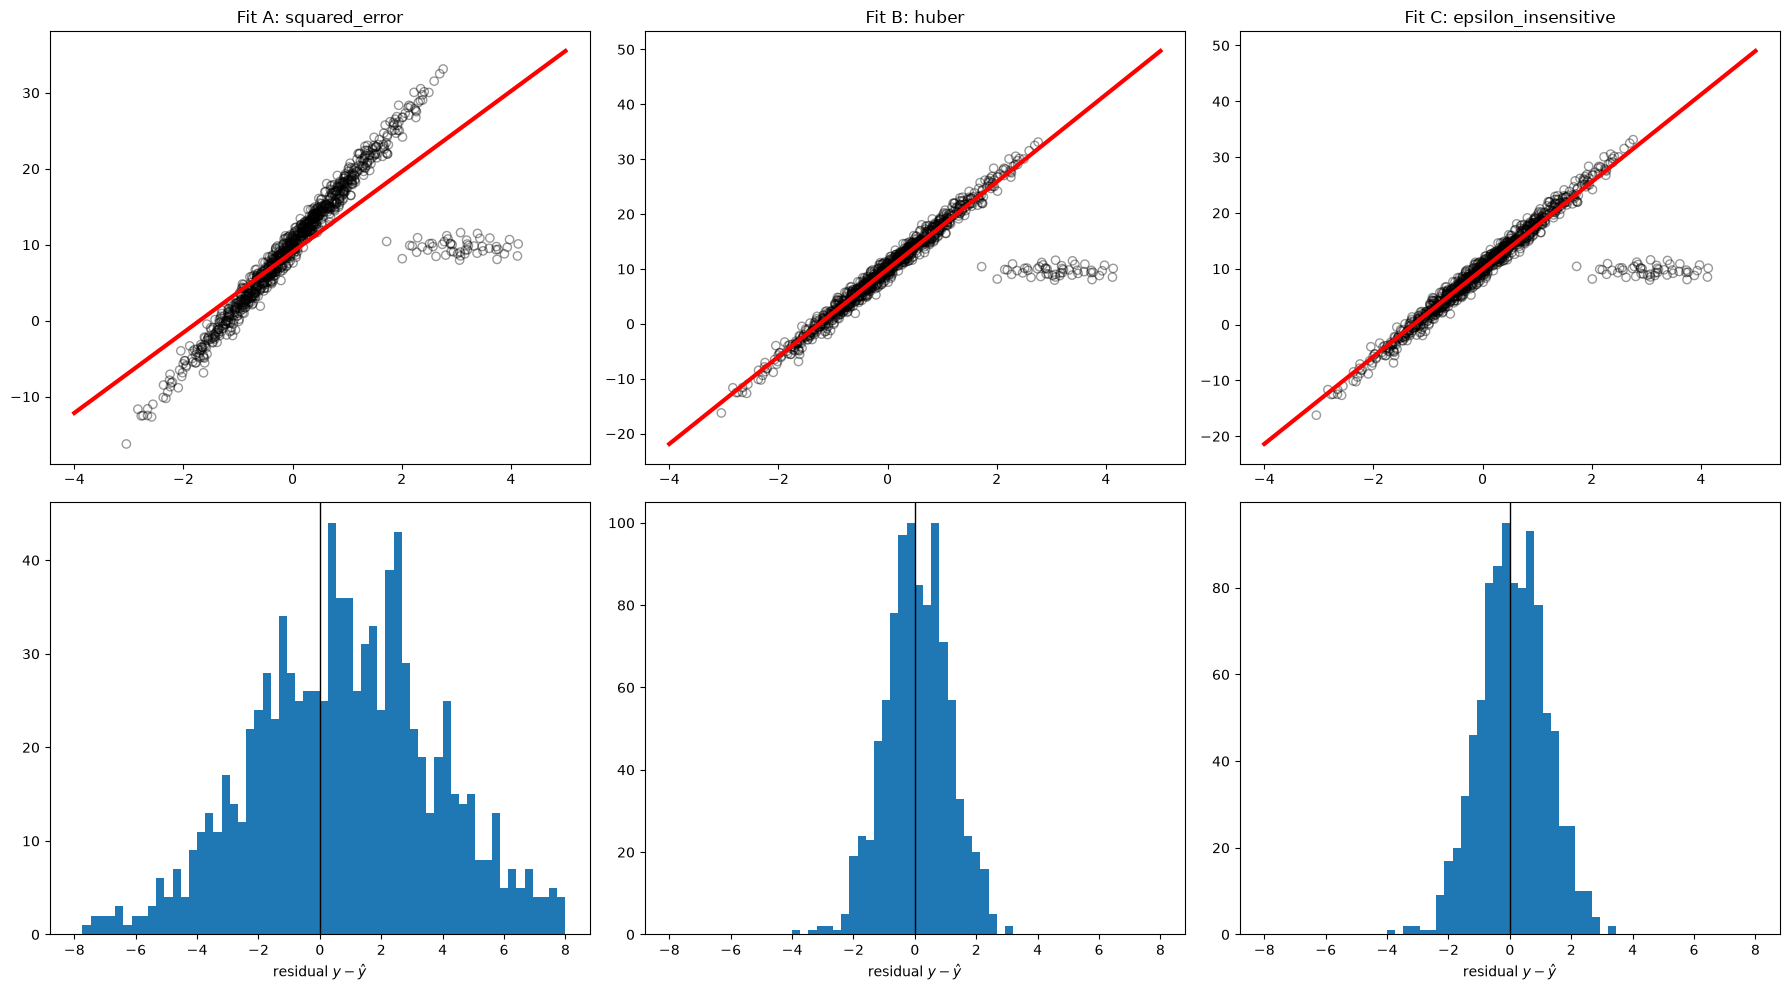

In [ ]:
ex4_losses = ['squared_error', 'huber', 'epsilon_insensitive']
ex4_panel_order = np.random.default_rng(4).permutation(len(ex4_losses))
print("Fit -> loss:", {letter: ex4_losses[j] for letter, j in zip("ABC", ex4_panel_order)})
print(f"True slope of the bulk of the data: {true_slope_outliers:.3f}, true intercept: 10")

ex4_line_X = np.linspace(-4, 5, 50)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for panel, j in enumerate(ex4_panel_order):
    ex4_model = SGDRegressor(loss=ex4_losses[j], fit_intercept=True, max_iter=20000,
                             penalty='l2', alpha=.001, epsilon=1, tol=1e-5, random_state=0)
    ex4_model.fit(Xr, yr)
    residuals = yr - ex4_model.predict(Xr)
    print(f"Fit {'ABC'[panel]} ({ex4_losses[j]:>20s}): slope {ex4_model.coef_[0]:.2f}, intercept {ex4_model.intercept_[0]:.2f}, "
          f"median residual of the non-outliers {np.median(residuals[n_outliers:]):.2f}")
    ax_fit, ax_hist = axes[0, panel], axes[1, panel]
    ax_fit.scatter(Xr, yr, facecolors='None', edgecolors='k', alpha=0.4)
    ax_fit.plot(ex4_line_X, ex4_model.predict(ex4_line_X[:, np.newaxis]), 'r-', lw=3)
    ax_fit.set_title(f"Fit {'ABC'[panel]}: {ex4_losses[j]}")
    ax_hist.hist(residuals, bins=60, range=(-8, 8))
    ax_hist.axvline(0, color='k', lw=1)
    ax_hist.set_xlabel(r"residual $y - \hat{y}$")
plt.tight_layout()
plt.show()

**(a)** The odd one out is the **squared loss**. There are two give-aways for this. First, in its residual histogram the bulk of the residuals are shifted away from zero (the line has been dragged towards the outlier cluster, so the good points are systematically mis-predicted), and the histogram is much *wider* than the others, because a tilted line produces residuals that grow with $|x|$. Second, in the fit itself you can see the line cutting through the point cloud at the wrong angle, with the outliers rewarded by a smaller residual than they deserve.

**(b)** The Huber and epsilon-insensitive fits are practically identical, and you cannot tell them apart from these plots. Look at the loss-shape plot in the chapter: for large errors *both* losses grow linearly, so the fifty outliers exert the same constant pull under either loss. They only differ for errors smaller than about one unit (quadratic versus a flat dead band followed by a linear ramp), and inside the bulk of the data this difference would not produce a notable change in the line or fit.

**(c)** They would separate when the *small* errors matter: for example, with very few data points, with no outliers at all (the squared part of Huber then behaves like the ordinary squared loss, whereas a wide dead band makes the epsilon-insensitive fit indifferent to where exactly it sits inside the band), or when the noise is skewed so that the mean and the median of the bulk differ.

### Exercise 5: Where do these points sit on the hinge loss?

The code recomputes the hinge-loss classifier, the six highlighted points and, for each, its class, decision value $f(\mathbf{x})$, signed margin $z = y\,f(\mathbf{x})$ and hinge loss.

In [ ]:
X_moons, y_moons = datasets[0]
X_moons = StandardScaler().fit_transform(X_moons)
y_moons_pm = np.where(y_moons == 1, 1, -1)

svm_moons = LinearSVC(loss='hinge', C=1.0, max_iter=200000, tol=1e-8)
svm_moons.fit(X_moons, y_moons)
f_moons = svm_moons.decision_function(X_moons)
z_moons = y_moons_pm * f_moons


def closest_point(target, exclude):
    """Index of the point whose signed margin is closest to target, skipping excluded indices."""
    distance = np.abs(z_moons - target).astype(float)
    distance[list(exclude)] = np.inf
    return int(np.argmin(distance))


on_margin = [int(i) for i in np.where(np.abs(z_moons - 1) < 1e-3)[0][:2]]
chosen = list(on_margin)
for target in [0.5, 2.0, -1.0, z_moons.min()]:
    chosen.append(closest_point(target, chosen))
ex5_points = [chosen[i] for i in np.random.default_rng(5).permutation(len(chosen))]

marks = {"A": 1.0, "B": 0.0, "C": -1.0, "D": 2.0}
print(" point  class    f(x)      z   hinge loss  nearest mark")
for number, idx in enumerate(ex5_points, start=1):
    z = z_moons[idx]
    if 0.05 < z < 0.95:
        nearest = "between B and A"
    else:
        nearest = min(marks, key=lambda letter: abs(marks[letter] - z))
    print(f"   {number}     {y_moons_pm[idx]:+d}   {f_moons[idx]:6.2f}  {z:6.2f}     {max(0, 1 - z):5.2f}        {nearest}")

 point  class    f(x)      z   hinge loss  nearest mark
   1     +1     1.00    1.00      0.00        A
   2     -1     1.08   -1.08      2.08        C
   3     -1    -0.50    0.50      0.50        between B and A
   4     -1    -2.01    2.01      0.00        D
   5     -1     1.64   -1.64      2.64        C
   6     -1    -1.00    1.00      0.00        A


**(a)** Read the class from the marker and the position from the lines. A point is *correctly* classified when it lies on its own class's side of the solid line, so a $+$ below the line or an $\circ$ above it has $z > 0$. A point exactly on a dashed line has $|f| = 1$: on its own side that means $z = 1$ (mark A, the kink), on the wrong side $z = -1$ (mark C). A point beyond its own dashed line has $z > 1$ (mark D), and a point between the solid and dashed lines on the correct side has $0 < z < 1$ (between B and A). The table above gives the exact values.

**(b)** Zero loss requires $z \ge 1$: the two points sitting exactly on their own dashed line (mark A) and the point far beyond it (mark D). Only the two dashed-line points are *at the kink*.

**(c)** The point at mark D can be deleted (or moved a little) without changing anything: its loss is zero and it is not at the kink, so the optimum does not depend on it. The other five are support vectors: the two at the kink because they define where the margin sits, and the three with positive loss because they push on the boundary.

### Exercise 6: Name the classification loss

In [ ]:
def modified_huber_loss(y_true, y_pred):
    """Modified Huber loss from the chapter, as a function of the signed margin z = y_true * y_pred."""
    z = y_pred * y_true
    loss_values = -4 * z
    loss_values[z >= -1] = (1 - z[z >= -1]) ** 2
    loss_values[z >= 1.] = 0
    return loss_values


ex6_losses = {
    'hinge': lambda z: np.where(z < 1, 1 - z, 0),
    'perceptron': lambda z: -np.minimum(z, 0),
    'log_loss': lambda z: np.log2(1 + np.exp(-z)),
    'modified_huber': lambda z: modified_huber_loss(z, np.ones_like(z)),
    'squared_hinge': lambda z: np.where(z < 1, 1 - z, 0) ** 2,
}
ex6_names = list(ex6_losses)
ex6_label_order = np.random.default_rng(6).permutation(len(ex6_names))
print("Loss letter -> loss:", {letter: ex6_names[j] for letter, j in zip("ABCDE", ex6_label_order)})

ex6_point_order = sorted(range(len(ex5_points)), key=lambda k: z_moons[ex5_points[k]])
ex6_numbers = [k + 1 for k in ex6_point_order]
ex6_z = np.array([z_moons[ex5_points[k]] for k in ex6_point_order])

print("\n point     z  " + "".join(f"{name:>16s}" for name in ex6_names))
for number, z in zip(ex6_numbers, ex6_z):
    values = "".join(f"{ex6_losses[name](np.array([z]))[0]:16.2f}" for name in ex6_names)
    print(f"   {number}   {z:5.2f}" + values)

Loss letter -> loss: {'A': 'log_loss', 'B': 'squared_hinge', 'C': 'hinge', 'D': 'modified_huber', 'E': 'perceptron'}

 point     z             hinge      perceptron        log_loss  modified_huber   squared_hinge
   5   -1.64            2.64            1.64            2.62            6.57            6.98
   2   -1.08            2.08            1.08            1.98            4.31            4.32
   3    0.50            0.50           -0.00            0.68            0.25            0.25
   1    1.00            0.00           -0.00            0.45            0.00            0.00
   6    1.00            0.00           -0.00            0.45            0.00            0.00
   4    2.01            0.00           -0.00            0.18            0.00            0.00


**(a)** The identifying features, from the leftmost (most misclassified) point rightwards:

- **Log loss** is the only curve that never reaches zero: even the most confidently classified point still contributes a little. It also grows only linearly on the left.
- **Hinge loss** is a straight line on the left ($1 - z$) and exactly zero for every point with $z \ge 1$, including the two on the margin. Reading $z = 1 - \text{hinge}$ off this curve gives you the signed margin of every point.
- **Perceptron loss** is zero for *every* correctly classified point, including the one inside the margin, and equals $-z$ for misclassified points, so it is the lowest curve on the left.
- **Squared hinge** is the hinge value squared: it is the highest curve on the left (7 for $z \approx -1.6$) and zero from the margin onwards.
- **Modified Huber** agrees with squared hinge for $z > -1$ but switches to the straight line $-4z$ below that, so it sits slightly *under* the squared hinge at the most misclassified point (6.6 versus 7.0). That small gap is the only place the two differ.

**(b)** The perceptron loss and the hinge loss give exactly zero for correctly classified points, but with an important difference: the perceptron is satisfied by *any* correctly classified point, however close to the boundary, while the hinge only switches off once the point is beyond the margin. That is why the perceptron has no preferred boundary and lands somewhere different every time you retrain it (the behaviour you saw in the chapter's experiment), whereas the hinge loss keeps pushing until the boundary sits in the middle of the gap between the classes.

### Exercise 7: Choose the penalty

**(a)** An $L_1$ penalty (the LASSO). With 40 candidate features, you want most weights to be *exactly* zero, and only the $L_1$ penalty geometry will encourage that. Be aware of the catch with strongly correlated features: the LASSO tends to pick one of a correlated group more or less arbitrarily and zero the rest, so the "important" list can change if the data change slightly. If that matters, an Elastic Net (an $L_1$ plus a small $L_2$ term) keeps the sparsity while sharing weight among correlated features.

**(b)** An $L_2$ penalty (ridge regression). Nearly redundant inputs make the unpenalized problem ill-conditioned: many different weight vectors fit almost equally well, so small changes in the monthly data can cause the coefficients to swing wildly. The $L_2$ penalty makes the problem well-posed and spreads the weight smoothly across the redundant channels, which is exactly the stability the plant engineers were asking you for. An $L_1$ penalty would do the opposite here, flipping which redundant channel gets the weight from month to month.

### Exercise 8: Which penalty produced this path?

Panel -> p: {'A': 0.5, 'B': 1, 'C': 2, 'D': 100}
The blue path was computed with p = 1, so panel B is the consistent one.


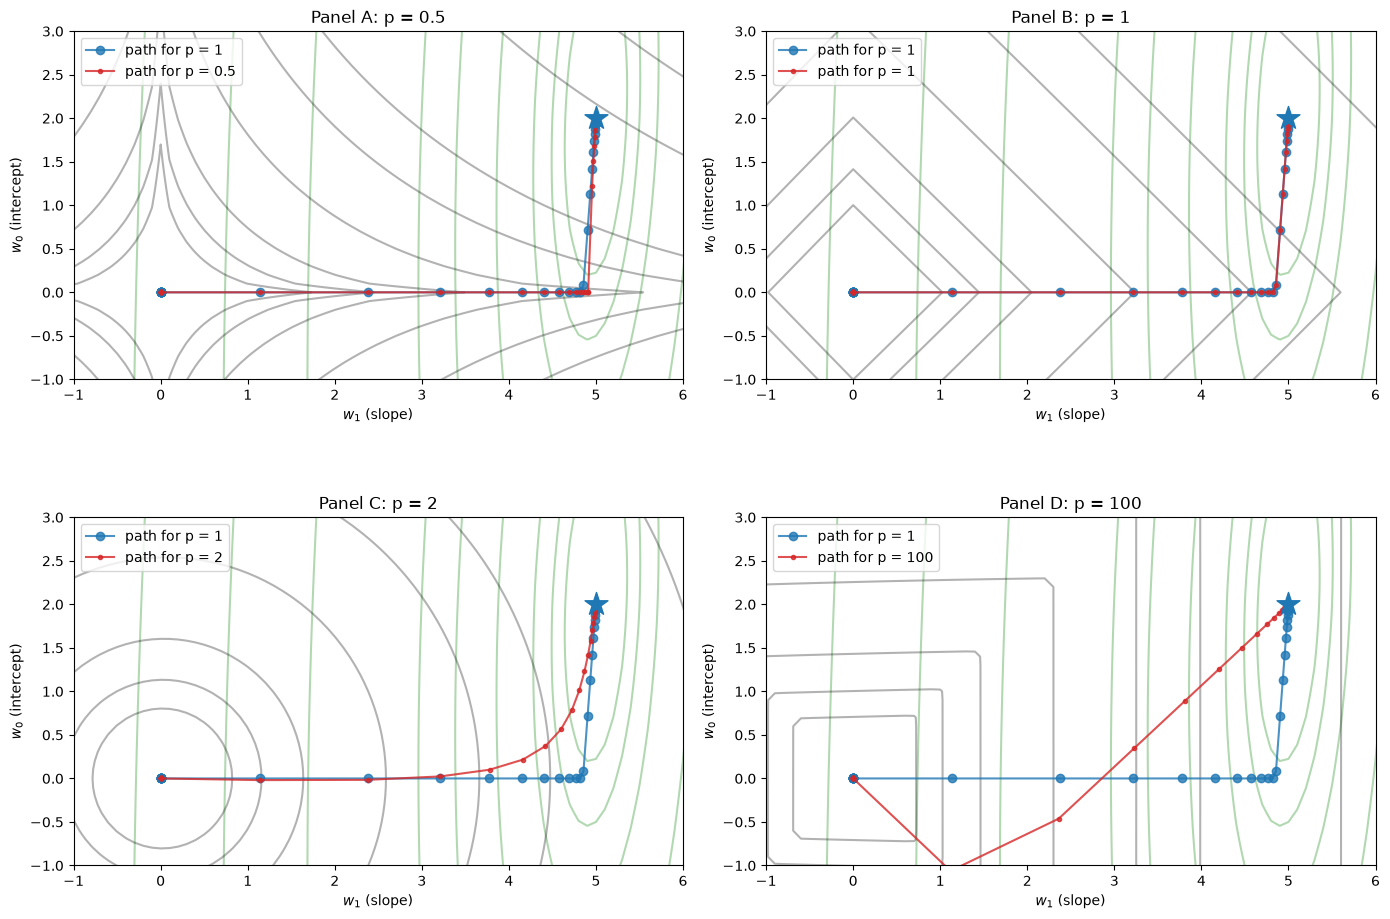

In [ ]:
ex8_orders = [0.5, 1, 2, 100]
ex8_path_p = 1
ex8_path = ex3_paths[ex3_orders.index(ex8_path_p)]
print("Panel -> p:", dict(zip("ABCD", ex8_orders)))
print(f"The blue path was computed with p = {ex8_path_p}, so panel {'ABCD'[ex8_orders.index(ex8_path_p)]} is the consistent one.")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for panel, (ax, o) in enumerate(zip(axes.ravel(), ex8_orders)):
    Z_noalpha, Z, Amin, Bmin = generate_z_grid(10000, o)
    ax.contour(A, B, Z_noalpha, 10, levels=get_levels(Z_noalpha), linestyles='solid', alpha=0.3, colors='g')
    ax.contour(A, B, Z, 10, levels=get_levels(Z), linestyles='solid', alpha=0.3, colors='k')
    ax.plot(ex8_path[:, 0], ex8_path[:, 1], marker='o', alpha=0.8, label=f"path for p = {ex8_path_p}")
    ax.plot(ex3_paths[j := ex3_orders.index(o)][:, 0], ex3_paths[j][:, 1], marker='.', alpha=0.8,
            color='C3', label=f"path for p = {o}")
    ax.scatter([w1_true], [w0_true], marker='*', s=300, zorder=5)
    ax.set_title(f"Panel {'ABCD'[panel]}: p = {o}")
    ax.set_xlabel("$w_1$ (slope)")
    ax.set_ylabel("$w_0$ (intercept)")
    ax.set_xlim([-1, 6])
    ax.set_ylim([-1, 3])
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**(a)** The grey contours give the norm away: the star-shaped, inward-curving contours are $p = 0.5$; the diamond is $p = 1$; the circle is $p = 2$; the rounded square is $p = 100$.

**(b)** The blue path was computed with $p = 1$, and only the diamond panel is consistent with how the path should intersect the norm constraint with the lowest value in the loss function. The path first runs straight down to the axis $w_0 = 0$ and then slides along the axis towards the origin. Sliding *along an axis* means the optimum sits at a corner of the penalty contour, and only the diamond (and the star) have corners on the axes. The star can be ruled out because its optimum would jump to the axis abruptly at a much smaller penalty rather than descend gradually, and the circle and the square have no axis corners at all: the circle would bend the path smoothly towards the origin without ever touching the axis until the very end, and the square would first shrink the *larger* coefficient until the two were equal.

**(c)** The red paths in the figure show what actually happens for each $p$: the abrupt jump for $p = 0.5$, the smooth curve for $p = 2$ that keeps $w_0 > 0$, and the "shrink the slope first, then both together" path for $p = 100$.

### Exercise 9: Tracking a thrown object with a flaky lidar

**(a)** A ball in free flight follows $h(t) = h_0 + v_0 t - \tfrac{1}{2} g t^2$. That is a linear model in the parameters $(h_0, v_0, -g/2)$ with features $[1, t, t^2]$: the launch height, the launch speed, and minus half the gravitational acceleration.

**(b)** The dropped readings are outliers with a very specific structure: they all sit at exactly zero, far below the trajectory, and they are about one reading in eight. A squared loss squares those huge errors and lets them dominate the fit. A **Huber loss** (or an absolute loss) grows only linearly for large errors, so the dropouts pull with a bounded, constant force and the many good readings win. `HuberRegressor` fits the Huber loss directly and is not fussy about feature scaling.

**(c) and (d)** Below, the Huber fit next to the squared-loss fit.

    Huber loss: h0 =  1.49 m, v0 = 11.97 m/s, g =  9.79 m/s^2
  squared loss: h0 =  1.26 m, v0 =  9.33 m/s, g =  7.44 m/s^2
         truth: h0 =  1.50 m, v0 = 12.00 m/s, g =  9.81 m/s^2   (13 of 80 readings dropped)


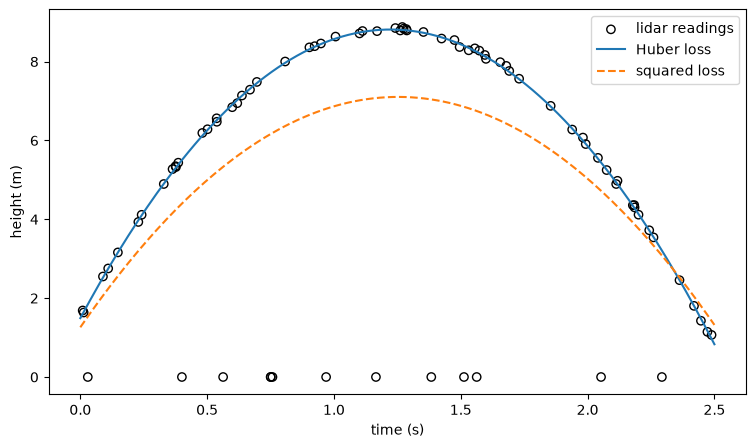

In [ ]:
lidar_rng = np.random.default_rng(7)
t_lidar = np.sort(lidar_rng.uniform(0.0, 2.5, 80))
height_lidar = 1.5 + 12.0 * t_lidar - 0.5 * 9.81 * t_lidar**2
height_lidar = height_lidar + lidar_rng.normal(0.0, 0.05, t_lidar.size)
lidar_missed = lidar_rng.random(t_lidar.size) < 0.12
height_lidar[lidar_missed] = 0.0


def trajectory_features(t):
    """Features [t, t^2] for the free-flight model; the intercept is the launch height."""
    return np.column_stack([t, t**2])


def report(name, model):
    """Print launch height, launch speed and g implied by a fitted model with features [t, t^2]."""
    launch_height = model.intercept_
    launch_speed, half_minus_g = model.coef_
    print(f"{name:>14s}: h0 = {launch_height:5.2f} m, v0 = {launch_speed:5.2f} m/s, g = {-2 * half_minus_g:5.2f} m/s^2")


huber_fit = HuberRegressor(epsilon=1.35, max_iter=1000).fit(trajectory_features(t_lidar), height_lidar)
squared_fit = LinearRegression().fit(trajectory_features(t_lidar), height_lidar)
report("Huber loss", huber_fit)
report("squared loss", squared_fit)
print(f"{'truth':>14s}: h0 =  1.50 m, v0 = 12.00 m/s, g =  9.81 m/s^2   ({lidar_missed.sum()} of {t_lidar.size} readings dropped)")

t_dense = np.linspace(0, 2.5, 200)
plt.figure(figsize=(9, 5))
plt.scatter(t_lidar, height_lidar, facecolors='none', edgecolors='k', label="lidar readings")
plt.plot(t_dense, huber_fit.predict(trajectory_features(t_dense)), label="Huber loss")
plt.plot(t_dense, squared_fit.predict(trajectory_features(t_dense)), '--', label="squared loss")
plt.xlabel("time (s)")
plt.ylabel("height (m)")
plt.legend()
plt.show()

The Huber fit recovers all three quantities to within a few percent of the truth. The squared-loss fit is dragged towards the zero readings: because the dropouts are spread over the whole flight, pulling the parabola down mostly reduces its *curvature*, so the estimate of $g$ suffers most, while the launch height is anchored by the early readings and moves least.

Note on implementation: if you use the vanilla `SGDRegressor(loss='huber')` from earlier in the chapter, the fact that $t$ and $t^2$ live on different scales can cause issues with basic stochastic gradient descent steps. If you want to do this, then standardize the features first (`StandardScaler`) and convert the coefficients back afterward.